In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='tab1')
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.xlsx to WA_Fn-UseC_-Telco-Customer-Churn.xlsx


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Para garantir que podemos reproduzir os dados
np.random.seed(123)

In [3]:
# Selecionar X sem ClientID e Outcome
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]

# Transformar colunas categóricas em variáveis dummy
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=123
)

In [19]:
# Criar modelo
rf_model = rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    max_depth=10,          # ✅ valor válido
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=123
)
# Treinar modelo
rf_model.fit(X_train, y_train)

# Ver modelo
print(rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=500, random_state=123)


SeniorCitizen: 0.0088
tenure: 0.0536
MonthlyCharges: 0.0559
gender_Male: 0.0476
Partner_Yes: 0.0080
Dependents_Yes: 0.0514
PhoneService_Yes: 0.0007
MultipleLines_No phone service: 0.0354
MultipleLines_Yes: 0.0190
InternetService_Fiber optic: 0.0443
InternetService_No: 0.0643
OnlineSecurity_No internet service: 0.0527
OnlineSecurity_Yes: 0.0483
OnlineBackup_No internet service: 0.0269
OnlineBackup_Yes: 0.0174
DeviceProtection_No internet service: 0.0504
DeviceProtection_Yes: 0.0105
TechSupport_No internet service: 0.0372
TechSupport_Yes: 0.0521
StreamingTV_No internet service: 0.0363
StreamingTV_Yes: 0.0202
StreamingMovies_No internet service: 0.0276
StreamingMovies_Yes: 0.0353
Contract_One year: 0.0201
Contract_Two year: 0.0244
PaperlessBilling_Yes: 0.0217
PaymentMethod_Credit card (automatic): 0.0259
PaymentMethod_Electronic check: 0.0525
PaymentMethod_Mailed check: 0.0123
TotalCharges_20: 0.0000
TotalCharges_21: 0.0000
TotalCharges_24: 0.0000
TotalCharges_25: 0.0000
TotalCharges_35: 

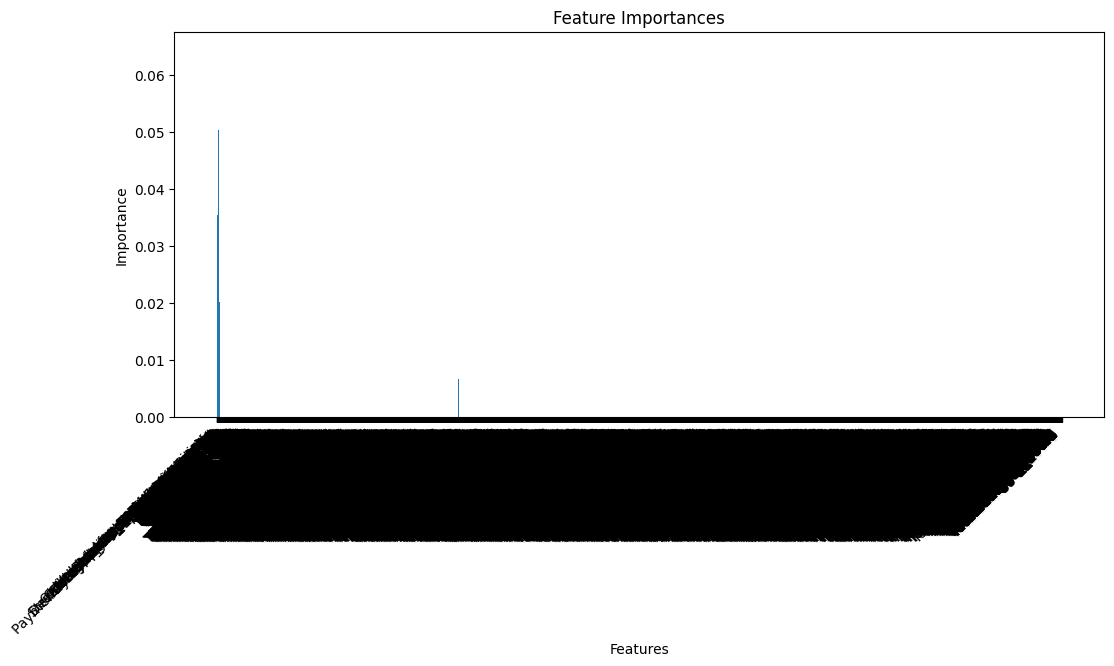

Confusion Matrix:
[[967 585]
 [ 83 478]]

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.62      0.74      1552
         Yes       0.45      0.85      0.59       561

    accuracy                           0.68      2113
   macro avg       0.69      0.74      0.67      2113
weighted avg       0.80      0.68      0.70      2113


One Client:
['Yes']


In [21]:
# 1️⃣ Importância das features
importances = rf_model.feature_importances_
for name, importance in zip(X_train.columns, importances):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(12,5))
plt.bar(X_train.columns, importances)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')  # rótulos girados para melhor leitura
plt.show()

# 3️⃣ Fazer previsões no conjunto de teste
predictions = rf_model.predict(X_test)

predict_One_Client = rf_model.predict(X_test.iloc[[4]])



# 4️⃣ Avaliar modelo
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))
print("\nOne Client:")
print(predict_One_Client)

In [22]:
# 1️⃣ Matriz de confusão simples
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, index=[0,1], columns=[0,1])  # garantir a ordem das classes
print("Confusion Matrix:")
print(cm_df)

# 2️⃣ Métricas detalhadas (precisão, recall, F1, suporte)
report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(report)

Confusion Matrix:
     0    1
0  967  585
1   83  478

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.62      0.74      1552
         Yes       0.45      0.85      0.59       561

    accuracy                           0.68      2113
   macro avg       0.69      0.74      0.67      2113
weighted avg       0.80      0.68      0.70      2113



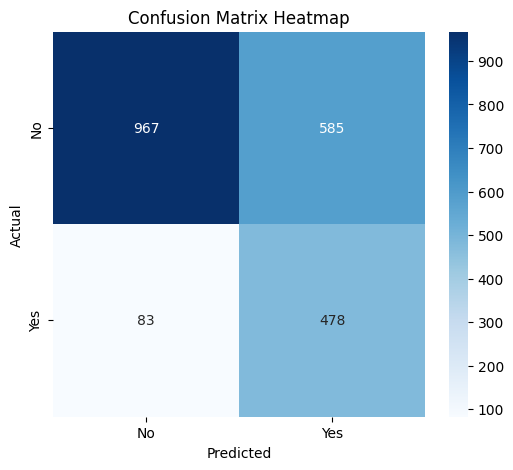

In [23]:
# Gerar matriz de confusão
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())

# Criar DataFrame para labels
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

# Plotar heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()